(1096, 3)


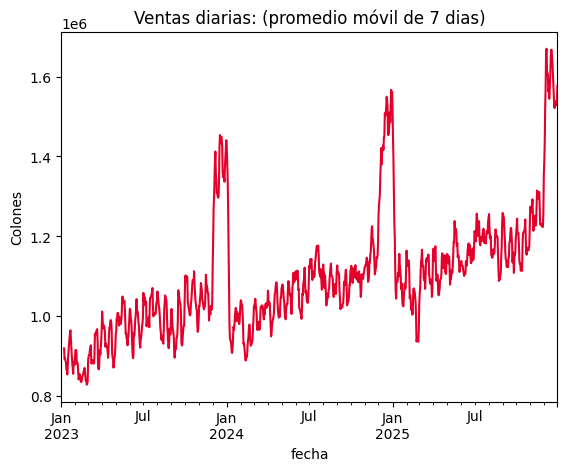

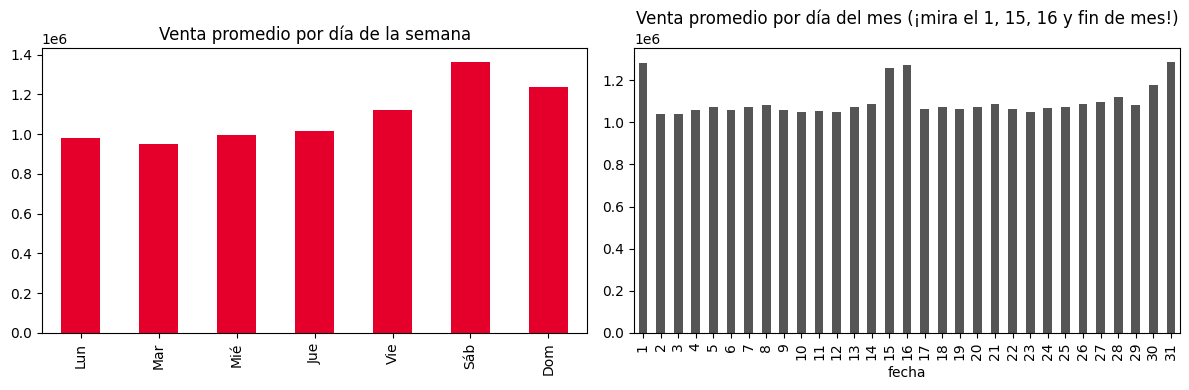

Entrenamiento: 1004 días | Prueba: 92 días
Linea base error promedio: ₡143,983 por dia (10.7%)


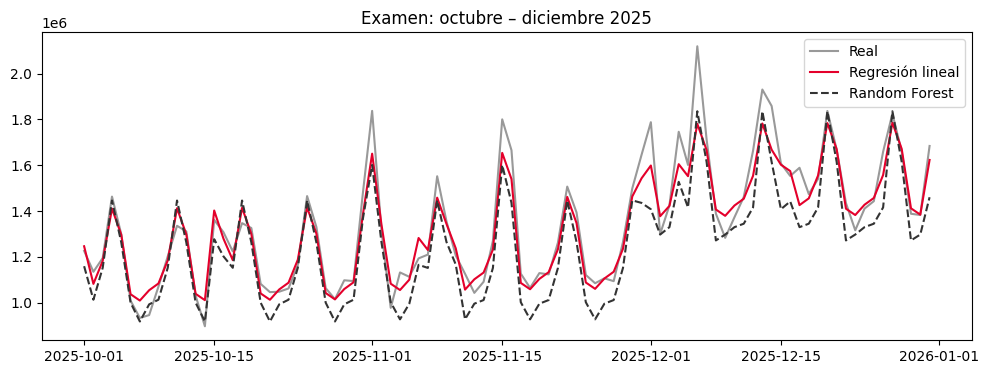

Crecimiento por día: ₡247  →  por año: ₡89,981
Efecto de una promoción: +₡152,538
Efecto de quincena:     +₡193,649


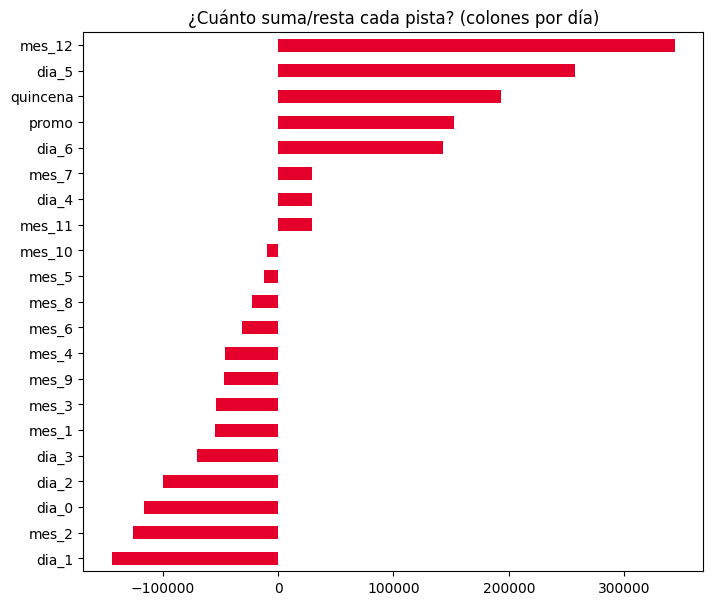

Venta total esperada en enero 2026: ₡37,070,000


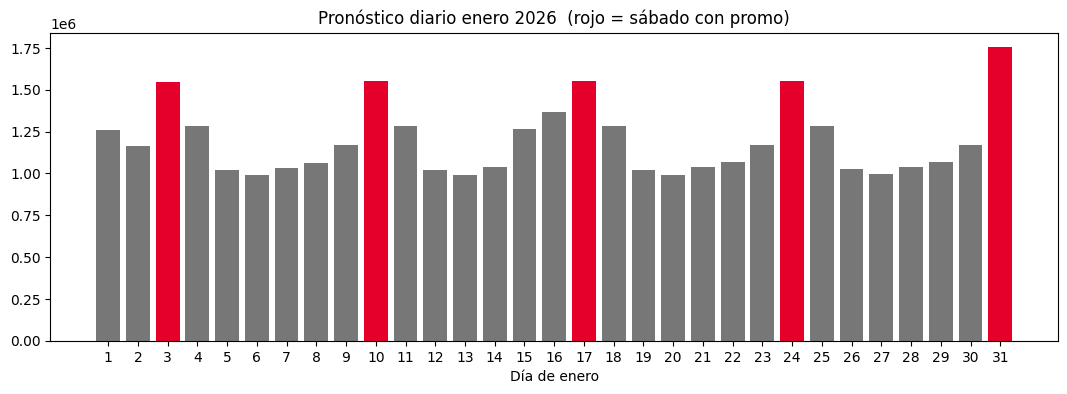

,dia,promo,pronostico,cajeros
0,Jue 01,0,1261000.0,4
1,Vie 02,0,1166000.0,4
2,Sáb 03,1,1549000.0,5
3,Dom 04,0,1281000.0,4
4,Lun 05,0,1019000.0,3
5,Mar 06,0,989000.0,3
6,Mié 07,0,1035000.0,3
7,Jue 08,0,1065000.0,4
8,Vie 09,0,1168000.0,4
9,Sáb 10,1,1551000.0,5


In [36]:
#Caso Práctio 1
# Predicción de ventas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

#Crear los datos del supermercado
rng = np.random.default_rng(42)
fechas = pd.date_range ("2023-01-01" , "2025-12-31", freq ="D")
n= len(fechas)

dia_semana = fechas.dayofweek
mes = fechas.month
dia = fechas.day
fin_de_mes = fechas.is_month_end

efecto_dia = np.array([0.90, 0.88, 0.92, 0.95, 1.05, 1.25, 1.15])[dia_semana]
efecto_mes = np.array([0.95, 0.88, 0.95, 0.97, 1.00, 0.98, 1.02, 0.98, 0.96, 0.99, 1.03, 1.30])[mes - 1]
quincena = ((dia == 15) | (dia == 16) | fin_de_mes | (dia == 1)).astype(int)
promo = (rng.random(n) < 0.12).astype(int)            # ~12 % de los días hay promo

tendencia = np. arange(n)
base = 900_000 + 250 * tendencia
ventas = base * efecto_dia* efecto_mes * (1 + 0.18 * quincena) * (1 + 0.15 * promo)
ventas = ventas * rng.normal (1,0.05,n)

df = pd.DataFrame ({
    "fecha": fechas,
    "promo": promo,
    "ventas": ventas.round(-2),
})

#Visualizar los datos

print (df.shape)
df.head(10)

#Mirar antes de predecir:

ax = df.set_index("fecha")["ventas"].rolling(7).mean().plot(color= "#E4002B", lw =1.5)
ax.set_title("Ventas diarias: (promedio móvil de 7 dias)")
ax.set_ylabel("Colones")
plt.show()

#segundo gráfico
nombres = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.groupby(df["fecha"].dt.dayofweek)["ventas"].mean().set_axis(nombres).plot.bar(ax=axes[0], color="#E4002B")
axes[0].set_title("Venta promedio por día de la semana")

df.groupby(df["fecha"].dt.day)["ventas"].mean().plot.bar(ax=axes[1], color="#555555")
axes[1].set_title("Venta promedio por día del mes (¡mira el 1, 15, 16 y fin de mes!)")
plt.tight_layout(); plt.show()

#Paso 3: COnvertir la fecha en pistas
#Paso 3 Convertir la fecha en pistas
def crear_pistas(tabla, fecha_inicio="2023-01-01"):
    t = pd.DataFrame(index=tabla.index)
    f = tabla["fecha"]
    t["tendencia"] = (f - pd.Timestamp(fecha_inicio)).dt.days
    t["quincena"] = (f.dt.day.isin([1, 15, 16]) | f.dt.is_month_end).astype(int)
    t["promo"] = tabla["promo"]
    t = t.join(pd.get_dummies(f.dt.dayofweek, prefix="dia").astype(int))
    t = t.join(pd.get_dummies(f.dt.month, prefix="mes").astype(int))
    return t

X = crear_pistas(df)
y = df["ventas"]
X.head()

#Paso 4: Separar respetando el tiempo

corte = df["fecha"] < "2025-10-01"
X_train, X_test = X[corte], X[~corte]
y_train, y_test = y[corte], y[~corte]
print(f"Entrenamiento: {len(X_train)} días | Prueba: {len(X_test)} días")

#Paso 5: La Línea base

pred_base = df["ventas"].shift(7)[~corte]   #misma venta de hace 7 dias
mae_base = mean_absolute_error(y_test, pred_base)
print(f"Linea base error promedio: ₡{mae_base:,.0f} por dia ({mae_base / y_test.mean():.1%})")


# Paso 6: Entrenar dos modelos y compararlos
modelos = {
    "Regresión lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
}

resultados = {"Línea base (semana pasada)": mae_base}
predicciones = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    p = modelo.predict(X_test)
    predicciones[nombre] = p
    resultados[nombre] = mean_absolute_error(y_test, p)

tabla = pd.DataFrame({"Error promedio diario (₡)": resultados})
tabla["Error %"] = (tabla["Error promedio diario (₡)"] / y_test.mean() * 100).map("{:.1f} %".format)
tabla.sort_values("Error promedio diario (₡)")
mejor = "Regresión lineal"
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.loc[~corte, "fecha"], y_test, color="#999999", label="Real")
ax.plot(df.loc[~corte, "fecha"], predicciones[mejor], color="#E4002B", label=mejor)
ax.plot(df.loc[~corte, "fecha"], predicciones["Random Forest"], color="#333333", ls="--", label="Random Forest")
ax.set_title("Examen: octubre – diciembre 2025"); ax.legend(); plt.show()

# Paso 7 Qué aprendió el modelo

lr = modelos["Regresión lineal"]
coef = pd.Series(lr.coef_, index=X.columns)
print(f"Crecimiento por día: ₡{coef['tendencia']:,.0f}  →  por año: ₡{coef['tendencia']*365:,.0f}")
print(f"Efecto de una promoción: +₡{coef['promo']:,.0f}")
print(f"Efecto de quincena:     +₡{coef['quincena']:,.0f}")
coef.drop(["tendencia"]).sort_values().plot.barh(figsize=(8, 7), color="#E4002B")
plt.title("¿Cuánto suma/resta cada pista? (colones por día)"); plt.show()

#Paso 8 Predir el futuro: enero 2026
lr_final = LinearRegression().fit(X, y)
enero = pd.DataFrame({"fecha": pd.date_range("2026-01-01", "2026-01-31", freq="D")})
enero["promo"] = (enero["fecha"].dt.dayofweek == 5).astype(int)     # promo los sábados
X_enero = crear_pistas(enero).reindex(columns=X.columns, fill_value=0)
enero["pronostico"] = lr_final.predict(X_enero).round(-3)
print(f"Venta total esperada en enero 2026: ₡{enero['pronostico'].sum():,.0f}")
enero.head(10)

#Hacer un grafico para el pronostico de enero 2026
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(enero["fecha"].dt.day, enero["pronostico"], color=np.where(enero["promo"] == 1, "#E4002B", "#777777"))
ax.set_xticks(range(1, 32)); ax.set_xlabel("Día de enero")
ax.set_title("Pronóstico diario enero 2026  (rojo = sábado con promo)"); plt.show()

#Paso 9 Dar la prediccion
enero["cajeros"] = np.maximum(3, np.ceil(enero["pronostico"] / 350_000)).astype(int)
plan = enero.assign(dia=[f"{nombres[d.dayofweek]} {d.day:02d}" for d in enero["fecha"]])[["dia", "promo", "pronostico", "cajeros"]]
plan.head(14)
